In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
from scipy.stats import chi2_contingency
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, recall_score, confusion_matrix, ConfusionMatrixDisplay, roc_curve, RocCurveDisplay, precision_score
from sklearn.model_selection import GridSearchCV



In [2]:
df_train = pd.read_parquet('train.parquet')
df_test = pd.read_parquet('test.parquet')

In [3]:
# df_user = df_train.groupby('userId').agg(
#     churn_flag=('churn_flag', 'max'),
#     pages=('page', lambda x: list(x))
# )

# all_pages = ['NextSong', 'Downgrade', 'Help', 'Home', 'Thumbs Up', 
#              'Add Friend', 'Thumbs Down', 'Add to Playlist', 'Logout',
#              'About', 'Settings', 'Save Settings', 'Cancel', 
#              'Cancellation Confirmation', 'Submit Downgrade', 'Roll Advert',
#              'Upgrade', 'Error', 'Submit Upgrade']

# for p in all_pages:
#     df_user[p] = df_user['pages'].apply(lambda x: int(p in x))

# X = df_user[all_pages]
# y = df_user['churn_flag']

# clf = LogisticRegression(penalty='l2', solver='liblinear', max_iter=1000)
# clf.fit(X, y)

# coef_table = pd.DataFrame({
#     'page': X.columns,
#     'coef': clf.coef_[0],
#     'odds_ratio': np.exp(clf.coef_[0])
# }).sort_values('odds_ratio', ascending=False)

# print(coef_table)


# Chi^2 test for checking feature significance (here status, but used previously for others)
# contingency = pd.crosstab(df_train['status'], df_train['churn_flag'])

# # run chi-square test
# chi2, p, dof, expected = chi2_contingency(contingency)

# print("Chi-square statistic:", chi2)
# print("Degrees of freedom:", dof)
# print("p-value:", p)



In [4]:
# Weights from Logistic Regression model (Done above)
churn_pages = {
    'Cancel': 7,
    'Cancellation Confirmation': 7,
    'Downgrade': 0.16,
    'Submit Upgrade': 0.14,
    'Upgrade': 0.03,
    'Settings': 0.02,
    'Submit Downgrade': 0.01
}
retain_pages = {
    'Save Settings': -0.0007,
    'Thumbs Down': -0.016,
    'About': -0.054,
    'Help': -0.058,
    'Add Friend': -0.158,
    'Add to Playlist': -0.383,
    'Roll Advert': -0.422,
    'Thumbs Up': -0.716,
    'Home': -1.423,
    'NextSong': -1.925
}

def compute_cumulative_risk(user_df):
    churn_score = 0
    not_churn_score = 0
    churn_list = []
    not_churn_list = []
        
    for page in user_df['page']:
        churn_score += churn_pages.get(page, 0)
        not_churn_score += retain_pages.get(page, 0)
        churn_list.append(churn_score)
        not_churn_list.append(not_churn_score)
        
    user_df['churn_risk_score'] = churn_list
    user_df['not_churn_score'] = not_churn_list
    return user_df


def forward_looking_churn(df, prediction_window_days=10, buffer_days=0):
    df = df.sort_values(['userId', 'ts']).reset_index(drop=True)
    
    churn_events = df[df['churn_flag'] == 1].groupby('userId')['ts'].min().reset_index()
    churn_events.columns = ['userId', 'churn_time']
    
    df = df.merge(churn_events, on='userId', how='left')
    
    df['days_until_churn'] = (df['churn_time'] - df['ts']).dt.total_seconds() / 86400
    
    
    df['will_churn_in_10d'] = (
        (df['days_until_churn'] >= 0) &
        (df['days_until_churn'] <= prediction_window_days)
    ).astype(int)
    
    df['will_churn_in_10d'] = df['will_churn_in_10d'].fillna(0).astype(int)
    
    
    if buffer_days > 0:
        mask_keep = (df['days_until_churn'].isna()) | (df['days_until_churn'] > buffer_days)
        df_clean = df[mask_keep].copy()
    else:
        mask_keep = (df['days_until_churn'].isna()) | (df['days_until_churn'] > 0)
        df_clean = df[mask_keep].copy()
    
    def filter_non_churner_tail(user_df):
        if user_df['churn_time'].isna().all():
            max_time = user_df['ts'].max()
            cutoff = max_time - pd.Timedelta(days=prediction_window_days)
            return user_df[user_df['ts'] <= cutoff]
        return user_df
    
    df_clean = df_clean.groupby('userId', group_keys=False).apply(filter_non_churner_tail)
    
    df_clean = df_clean.drop(columns=['churn_time', 'days_until_churn', 'churn_flag'])
    
    return df_clean.reset_index(drop=True)


def feature_engineering(df, prediction_window_days=10, buffer_days=0):
    df['churn_flag'] = ((df['auth'] == 'Cancelled') | 
                        (df['page'] == 'Cancellation Confirmation')).astype(int)
    
    df['ts'] = pd.to_datetime(df['ts'], unit='ms')
    df = df.sort_values(['userId', 'ts']).reset_index(drop=True)
    
    df['churn_risk_score'] = 0.0
    df['not_churn_score'] = 0.0
    
    df['level'] = df['level'].map({'free': 0, 'paid': 1})
    
    df['timeInSession'] = df.groupby('userId')['ts'].transform(
        lambda x: (x - x.min()).dt.total_seconds()
    )
    df['timeSinceRegistered'] = (df['ts'] - df['registration']).dt.total_seconds()
    
    df = df.groupby('userId', group_keys=False).apply(compute_cumulative_risk)
    
    df = forward_looking_churn(df, prediction_window_days, buffer_days)
    
    feats_kept = ['status', 'level', 'userId', 'itemInSession', 'timeSinceRegistered', 
                  'not_churn_score', 'churn_risk_score', 'timeInSession', 'ts']
    
    df_seq = df[feats_kept + ['will_churn_in_10d']].copy()
    
    # Diagnostic info
    print(f"Total rows after cleaning: {len(df_seq)}")
    print(f"Number of users: {df_seq['userId'].nunique()}")
    print(f"Churn rate (will churn in next {prediction_window_days} days): {df_seq['will_churn_in_10d'].mean():.2%}")
    print(f"Class distribution:\n{df_seq['will_churn_in_10d'].value_counts()}")
    
    user_churn = df_seq.groupby('userId')['will_churn_in_10d'].max()
    print(f"\nUsers who will churn: {user_churn.sum()}")
    print(f"Users who won't churn: {len(user_churn) - user_churn.sum()}")
    
    return df_seq


In [5]:
df_train = feature_engineering(df_train, buffer_days=1) # Remove leakage
df_test = feature_engineering(df_test)

df_train = df_train.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

/var/folders/rr/hj2x23vn64g9m265fnm93yd40000gn/T/ipykernel_76704/4200153681.py:98: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby('userId', group_keys=False).apply(compute_cumulative_risk)
/var/folders/rr/hj2x23vn64g9m265fnm93yd40000gn/T/ipykernel_76704/4200153681.py:74: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_clean = df_clean.groupby('userId', group_keys=False).apply(filter_non_chur

Total rows after cleaning: 12984498
Number of users: 17178
Churn rate (will churn in next 10 days): 10.05%
Class distribution:
will_churn_in_10d
0    11678917
1     1305581
Name: count, dtype: int64

Users who will churn: 3519
Users who won't churn: 13659


/var/folders/rr/hj2x23vn64g9m265fnm93yd40000gn/T/ipykernel_76704/4200153681.py:98: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby('userId', group_keys=False).apply(compute_cumulative_risk)
/var/folders/rr/hj2x23vn64g9m265fnm93yd40000gn/T/ipykernel_76704/4200153681.py:74: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_clean = df_clean.groupby('userId', group_keys=False).apply(filter_non_chur

Total rows after cleaning: 3262600
Number of users: 2773
Churn rate (will churn in next 10 days): 0.00%
Class distribution:
will_churn_in_10d
0    3262600
Name: count, dtype: int64

Users who will churn: 0
Users who won't churn: 2773


In [6]:
df_train[df_train['userId'] == '1000025']

,status,level,userId,itemInSession,timeSinceRegistered,not_churn_score,churn_risk_score,timeInSession,ts,will_churn_in_10d
0,200,0,1000025,0,7255761.0,-1.4230,0.00,0.0,2018-10-02 08:59:29,0
1,200,0,1000025,1,7255956.0,-3.3480,0.00,195.0,2018-10-02 09:02:44,0
2,200,0,1000025,2,7256207.0,-5.2730,0.00,446.0,2018-10-02 09:06:55,0
3,200,0,1000025,3,7256430.0,-7.1980,0.00,669.0,2018-10-02 09:10:38,0
4,200,0,1000025,4,7256623.0,-9.1230,0.00,862.0,2018-10-02 09:13:51,0
...,...,...,...,...,...,...,...,...,...,...
1748,200,1,1000025,137,8592480.0,-2973.4084,3.01,1336719.0,2018-10-17 20:18:08,1
1749,200,1,1000025,138,8592751.0,-2975.3334,3.01,1336990.0,2018-10-17 20:22:39,1
1750,200,1,1000025,139,8592936.0,-2977.2584,3.01,1337175.0,2018-10-17 20:25:44,1
1751,307,1,1000025,140,8592937.0,-2977.9744,3.01,1337176.0,2018-10-17 20:25:45,1


In [7]:
# # Basic and Naive EDA
# num_cols = df_train.select_dtypes(include=["int64", "float64"]).columns

# # Histograms
# for col in num_cols:
#     plt.figure()
#     df_train[col].hist()
#     plt.title(f"Histogram of {col}")
#     plt.xlabel(col)
#     plt.ylabel("Frequency")
#     plt.show()

# # Box plots
# for col in num_cols:
#     plt.figure()
#     df_train.boxplot(column=col)
#     plt.title(f"Box plot of {col}")
#     plt.ylabel(col)
#     plt.show()

In [8]:
models = {
    "logistic_regression": LogisticRegression(random_state=42, max_iter=10000),
    "decision_tree": DecisionTreeClassifier(max_depth=5, random_state=42),
    "Random_forest": RandomForestClassifier(
        n_estimators=150, max_depth=4, random_state=42
    ),
    "GBDT": GradientBoostingClassifier(n_estimators=150, max_depth=4, random_state=42),
    "XGBoost": xgb.XGBClassifier(n_estimators=200, max_depth=5, random_state=42),
    "ridge_regression": RidgeClassifier(random_state=42),
    "knn": KNeighborsClassifier(n_neighbors=5),
}

In [9]:
# Split by User to keep time series integrity

unique_users = df_train['userId'].unique()
train_users, val_users = train_test_split(unique_users, test_size=0.2, random_state=42)

train_mask = df_train['userId'].isin(train_users)
val_mask = df_train['userId'].isin(val_users)

X_train = df_train[train_mask].drop(columns=["will_churn_in_10d", "userId", "ts"])
y_train = df_train[train_mask]["will_churn_in_10d"]

X_val = df_train[val_mask].drop(columns=["will_churn_in_10d", "userId", "ts"])
y_val = df_train[val_mask]["will_churn_in_10d"]


For Model: logistic_regression
For Training Set:
Macro F1 Score: 0.4758123219503342
Confusion Matrix:


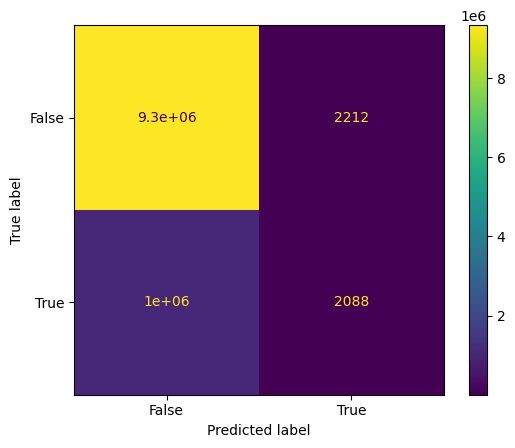

For Validation Set:
Macro F1 Score: 0.47243264483248404
Confusion Matrix:


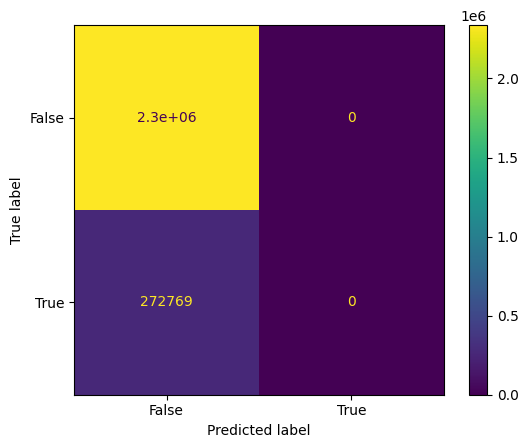

For Model: decision_tree
For Training Set:
Macro F1 Score: 0.5332423619088209
Confusion Matrix:


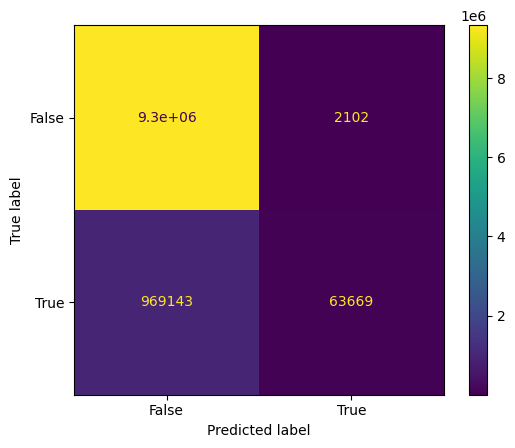

For Validation Set:
Macro F1 Score: 0.53008083491724
Confusion Matrix:


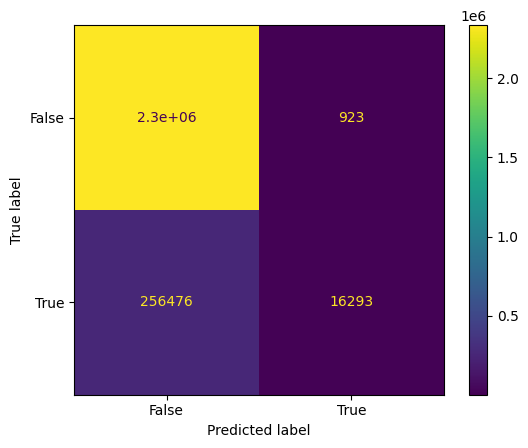

For Model: Random_forest
For Training Set:
Macro F1 Score: 0.5295027223542345
Confusion Matrix:


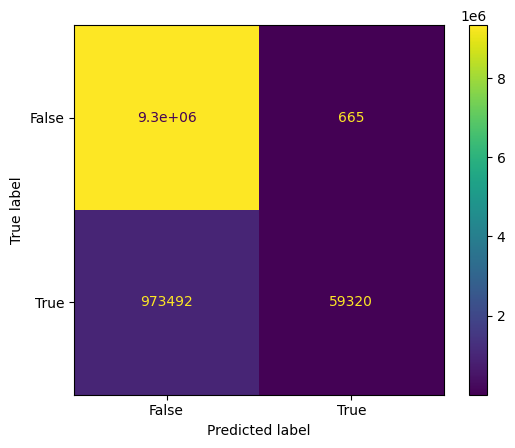

For Validation Set:
Macro F1 Score: 0.5287995986834758
Confusion Matrix:


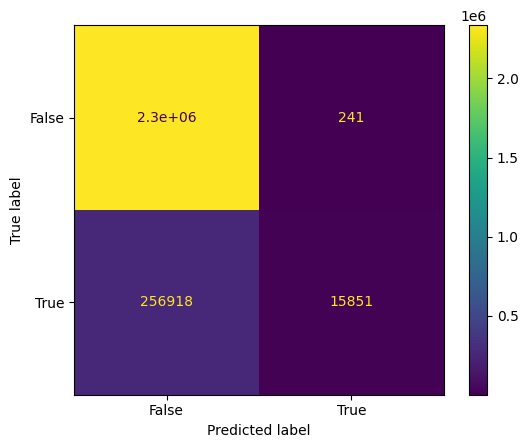

For Model: GBDT


KeyboardInterrupt: 

In [10]:
train_scores = []
test_scores = []
recall_test_scores = []

model_names = models.keys()

for model in model_names:
    print("For Model:", model)

    models[model].fit(X_train, y_train)

    print("For Training Set:")

    y_train_pred = models[model].predict(X_train)

    f1_train = f1_score(y_train, y_train_pred, average="macro")
    print("Macro F1 Score:", f1_train)

    print("Confusion Matrix:")
    conf_matrix = confusion_matrix(y_train, y_train_pred)
    cm_display = ConfusionMatrixDisplay(
        confusion_matrix=conf_matrix, display_labels=[False, True]
    )
    cm_display.plot()
    plt.show()

    print("For Validation Set:")

    y_test_pred = models[model].predict(X_val)

    f1_test = f1_score(y_val, y_test_pred, average="macro")
    print("Macro F1 Score:", f1_test)

    recall_test_score = recall_score(y_val, y_test_pred, average="macro")

    print("Confusion Matrix:")
    conf_matrix = confusion_matrix(y_val, y_test_pred)
    cm_display = ConfusionMatrixDisplay(
        confusion_matrix=conf_matrix, display_labels=[False, True]
    )
    cm_display.plot()
    plt.show()

    train_scores.append(f1_train)
    test_scores.append(f1_test)
    recall_test_scores.append(recall_test_score)



In [11]:
pip install lightgbm


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [25]:
pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.8/27.8 MB 126.3 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [catboost]1/2 [catboost]

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [ ]:
# Test complete pipeline with sessin & page sequence features

import pandas as pd
import numpy as np
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score
import warnings
warnings.filterwarnings('ignore')


# we load the data 

df_train = pd.read_parquet('train.parquet')
df_test = pd.read_parquet('test.parquet')

churn_pages = {
    'Cancel': 7, 'Cancellation Confirmation': 7, 'Downgrade': 0.16, # high rist
    'Submit Upgrade': 0.14, 'Upgrade': 0.03, 'Settings': 0.02, 'Submit Downgrade': 0.01 # low risk 
}

retain_pages = {
    'Save Settings': -0.0007, 'Thumbs Down': -0.016, 'About': -0.054, 'Help': -0.058, # low risk
    'Add Friend': -0.158, 'Add to Playlist': -0.383, 'Roll Advert': -0.422, # medium risk
    'Thumbs Up': -0.716, 'Home': -1.423, 'NextSong': -1.925 # high retention
}

def compute_cumulative_risk(user_df): # compute cumulative churn risk based on page visits
    churn_score = 0
    not_churn_score = 0
    churn_list = []
    not_churn_list = []
    
    for page in user_df['page']:
        churn_score += churn_pages.get(page, 0) # add chrun risk
        not_churn_score += retain_pages.get(page, 0) # add retention score
        churn_list.append(churn_score) # store cumulative scores
        not_churn_list.append(not_churn_score) # store cumulative scores
    
    user_df['churn_risk_score'] = churn_list # create a new column for churn risk
    user_df['not_churn_score'] = not_churn_list # create a new column for retention score
    return user_df

def forward_looking_churn(df, prediction_window_days=10, buffer_days=0): # label future churn within a prediction window
    df = df.sort_values(['userId', 'ts']).reset_index(drop=True) # sort by user and timestamp
    churn_events = df[df['churn_flag'] == 1].groupby('userId')['ts'].min().reset_index() # first churn event per user
    churn_events.columns = ['userId', 'churn_time'] # rename columns
    df = df.merge(churn_events, on='userId', how='left') # merge churn times
    df['days_until_churn'] = (df['churn_time'] - df['ts']).dt.total_seconds() / 86400 # days until churn 
    df['will_churn_in_10d'] = ((df['days_until_churn'] >= 0) & (df['days_until_churn'] <= prediction_window_days)).astype(int) # label churn with in 10 days
    df['will_churn_in_10d'] = df['will_churn_in_10d'].fillna(0).astype(int) # fill Nans with 0 
    
    if buffer_days > 0: # apply buffer to avoid data leakage 
        mask_keep = (df['days_until_churn'].isna()) | (df['days_until_churn'] > buffer_days) # filter rows
    else:
        mask_keep = (df['days_until_churn'].isna()) | (df['days_until_churn'] > 0) # filter rows
    df_clean = df[mask_keep].copy() # keep only valid rows
    
    def filter_non_churner_tail(user_df): # remove last 10 days for non churning customers 
        if user_df['churn_time'].isna().all(): # if user never churned
            max_time = user_df['ts'].max() # get max timestamp
            cutoff = max_time - pd.Timedelta(days=prediction_window_days) # define cutoff
            return user_df[user_df['ts'] <= cutoff] # filter rows 
        return user_df
    
    df_clean = df_clean.groupby('userId', group_keys=False).apply(filter_non_churner_tail) # apply filter per user
    df_clean = df_clean.drop(columns=['churn_time', 'days_until_churn', 'churn_flag']) # drop helper columns
    return df_clean.reset_index(drop=True) # reset index 


# Process train
df_train['churn_flag'] = ((df_train['auth'] == 'Cancelled') | (df_train['page'] == 'Cancellation Confirmation')).astype(int) # define churn flag
df_train['ts'] = pd.to_datetime(df_train['ts'], unit='ms') # convert timestamp
df_train = df_train.sort_values(['userId', 'ts']).reset_index(drop=True) # sort values 
df_train['churn_risk_score'] = 0.0 # initialize churn risk score
df_train['not_churn_score'] = 0.0 # initialize retention score
df_train['level'] = df_train['level'].map({'free': 0, 'paid': 1}) # map level to numeric
df_train['timeInSession'] = df_train.groupby('userId')['ts'].transform(lambda x: (x - x.min()).dt.total_seconds()) # time in session
df_train['timeSinceRegistered'] = (df_train['ts'] - df_train['registration']).dt.total_seconds() # time since registration
df_train = df_train.groupby('userId', group_keys=False).apply(compute_cumulative_risk) # compute cumulative risk
df_train = forward_looking_churn(df_train, prediction_window_days=10, buffer_days=1) # label futur churn 

# Process test
# Same steps as before but here with test data
df_test['churn_flag'] = ((df_test['auth'] == 'Cancelled') | (df_test['page'] == 'Cancellation Confirmation')).astype(int) 
df_test['ts'] = pd.to_datetime(df_test['ts'], unit='ms') 
df_test = df_test.sort_values(['userId', 'ts']).reset_index(drop=True)
df_test['churn_risk_score'] = 0.0
df_test['not_churn_score'] = 0.0
df_test['level'] = df_test['level'].map({'free': 0, 'paid': 1})
df_test['timeInSession'] = df_test.groupby('userId')['ts'].transform(lambda x: (x - x.min()).dt.total_seconds())
df_test['timeSinceRegistered'] = (df_test['ts'] - df_test['registration']).dt.total_seconds()
df_test = df_test.groupby('userId', group_keys=False).apply(compute_cumulative_risk)


#session level features
def create_session_features(df): # create featires based on session patterns    
    # Session-level aggregation
    session_stats = df.groupby(['userId', 'sessionId']).agg({ # aggregate per ssion 
        'itemInSession': 'max', # session length
        'churn_risk_score': 'last', # last churn risk score in session
        'not_churn_score': 'last', # last retention score in session
        'ts': ['min', 'max'] # session start and end times 
    }).reset_index()
    
    session_stats.columns = ['userId', 'sessionId', 'session_length', 'session_churn_risk', # flatten columns to single level 
                              'session_retain_score', 'session_start', 'session_end'] 
    
    session_stats['session_duration'] = (session_stats['session_end'] - session_stats['session_start']).dt.total_seconds() / 60 # session duration in minutes
    
    # User-level aggregation from sessions
    user_session_features = session_stats.groupby('userId').agg({ # aggregate per user
        'session_length': ['mean', 'std', 'max', 'min'], # session length stats
        'session_duration': ['mean', 'std', 'max', 'min'], # session duration stats
        'session_churn_risk': ['mean', 'std', 'max', 'last'], # churn risk stats
        'session_retain_score': ['mean', 'std', 'min', 'last'], # retention risk stats
        'sessionId': 'count'  # Number of sessions
    }).reset_index()
    
    user_session_features.columns = ['userId'] + ['_'.join(col).strip('_') for col in user_session_features.columns.values[1:]] # flatten columns to single level 
    
    # Session frequency
    session_gaps = session_stats.groupby('userId')['session_start'].apply(lambda x: x.diff().dt.total_seconds() / 3600).reset_index() # session gaps in hours 
    session_gap_stats = session_gaps.groupby('userId')['session_start'].agg(['mean', 'std']).reset_index() # mean and std of session gaps
    session_gap_stats.columns = ['userId', 'avg_session_gap_hours', 'std_session_gap_hours'] # reanme columns
    
    user_session_features = user_session_features.merge(session_gap_stats, on='userId', how='left') # merge session gap stats
    
    # Last session features (most predictive)
    last_sessions = session_stats.sort_values(['userId', 'session_start']).groupby('userId').tail(3) # last 3 sessions per user 
    last_session_agg = last_sessions.groupby('userId').agg({ # aggregae last session stats
        'session_length': 'mean', # average length
        'session_duration': 'mean', # average duration
        'session_churn_risk': 'mean' # average chrun risk 
    }).reset_index()
    last_session_agg.columns = ['userId', 'last3_avg_length', 'last3_avg_duration', 'last3_avg_risk'] # rename columns
    
    user_session_features = user_session_features.merge(last_session_agg, on='userId', how='left') # merge last sesion stats
    
    return user_session_features

train_session_features = create_session_features(df_train) # create session features for train 
test_session_features = create_session_features(df_test) # do the same for test 

#page interaction patterns
def create_page_features(df): # create features from page interaction patterns    
    # Count specific high-signal pages
    page_counts = df.groupby(['userId', 'page']).size().unstack(fill_value=0).reset_index()
    # Key pages
    key_pages = ['NextSong', 'Thumbs Up', 'Thumbs Down', 'Add to Playlist', # medium to high retention
                  #  'Add Friend', 'Cancel', 'Cancellation Confirmation',  high churn
                 'Home', 'Settings', 'Downgrade', 'Upgrade', 'Roll Advert']
    
    for page in key_pages:
        if page not in page_counts.columns: # ensure all key pages are present 
            page_counts[page] = 0 # add missing pages with 0 count 
    
    # Select only key pages
    page_features = page_counts[['userId'] + [p for p in key_pages if p in page_counts.columns]]
    
    # Rename columns
    page_features.columns = ['userId'] + [f'page_{col.lower().replace(" ", "_")}' for col in page_features.columns[1:]]
    
    # Add ratios
    total_events = df.groupby('userId').size().reset_index(name='total_events')
    page_features = page_features.merge(total_events, on='userId') # merge total events
    
    for col in page_features.columns:
        if col.startswith('page_'): # compute rations for page counts
            page_features[f'{col}_ratio'] = page_features[col] / (page_features['total_events'] + 1) # avoid diision by 0 
    
    return page_features

train_page_features = create_page_features(df_train) # create page features for train
test_page_features = create_page_features(df_test) # do the same for test 

#combine all features into final dataset
# Basic aggregation
train_basic = df_train.groupby('userId').agg({ # basic user level features
    'level': 'last',
    'churn_risk_score': 'max',
    'not_churn_score': 'min',
    'timeSinceRegistered': 'max',
    'will_churn_in_10d': 'max'
}).reset_index()

test_basic = df_test.groupby('userId').agg({ # basic user level features for test
    'level': 'last',
    'churn_risk_score': 'max',
    'not_churn_score': 'min',
    'timeSinceRegistered': 'max'
}).reset_index()

# Merge all
train_full = train_basic.merge(train_session_features, on='userId').merge(train_page_features, on='userId') # final train dataset
test_full = test_basic.merge(test_session_features, on='userId').merge(test_page_features, on='userId') # final test dataset

# Additional derived features
train_full['risk_per_session'] = train_full['churn_risk_score'] / (train_full['sessionId_count'] + 1) # risk per session
train_full['engagement_decline'] = train_full['session_length_mean'] - train_full['last3_avg_length'] # engagement decline
train_full['session_instability'] = train_full['session_length_std'] / (train_full['session_length_mean'] + 1) # session instability

test_full['risk_per_session'] = test_full['churn_risk_score'] / (test_full['sessionId_count'] + 1) # risk per session
test_full['engagement_decline'] = test_full['session_length_mean'] - test_full['last3_avg_length'] # engagement decline
test_full['session_instability'] = test_full['session_length_std'] / (test_full['session_length_mean'] + 1) # session instability 

# Prepare data
target_col = 'will_churn_in_10d' # target column name
X_user = train_full.drop(['userId', target_col], axis=1) # features
y_user = train_full[target_col] # target 

X_user = X_user.fillna(0) # fill nans with 0 
print(f"Total features: {X_user.shape[1]}, Churn rate: {y_user.mean():.2%}") # print feature count and churn rate 

X_train, X_val, y_train, y_val = train_test_split(X_user, y_user, test_size=0.2, random_state=42, stratify=y_user) # train val split 

scaler = StandardScaler() # standard scaling
X_train_scaled = scaler.fit_transform(X_train) # fit on train
X_val_scaled = scaler.transform(X_val) # transform val

scale_pos_weight = len(y_train[y_train==0]) / len(y_train[y_train==1]) # class weight

#hyperparameter tuning 
# XGBoost 
grid_xgb = GridSearchCV(
    xgb.XGBClassifier(random_state=42, eval_metric='logloss'),
    {
        'max_depth': [3, 5, 7, 9], # depth of trees
        'learning_rate': [0.005, 0.01, 0.03], # learning rate
        'n_estimators': [700, 1000, 1500], # number of trees
        'scale_pos_weight': [scale_pos_weight, scale_pos_weight*1.5], # class weight
        'subsample': [0.6, 0.8], # row sampling
        'colsample_bytree': [0.6, 0.8], # feature sampling
        'min_child_weight': [1, 3] # min child weight
    },
    cv=5, scoring='f1_macro', n_jobs=-1, verbose=1 # cross validation settings
)
grid_xgb.fit(X_train_scaled, y_train) # fit model
xgb_f1 = f1_score(y_val, grid_xgb.best_estimator_.predict(X_val_scaled), average='macro') # evaluate on val
print(f"XGBoost: CV={grid_xgb.best_score_:.4f}, Val={xgb_f1:.4f}")
print(f"Best params: {grid_xgb.best_params_}")

# LightGBM
grid_lgb = GridSearchCV(
    lgb.LGBMClassifier(random_state=42, verbose=-1),
    {
        'max_depth': [3, 5, 7, 9], # depth of trees
        'learning_rate': [0.005, 0.01, 0.03], # learning rate
        'n_estimators': [700, 1000, 1500], # number of trees
        'scale_pos_weight': [scale_pos_weight, scale_pos_weight*1.5], # class weight
        'num_leaves': [31, 63, 127] # number of leaves
    },
    cv=5, scoring='f1_macro', n_jobs=-1, verbose=1
)
grid_lgb.fit(X_train_scaled, y_train)
lgb_f1 = f1_score(y_val, grid_lgb.best_estimator_.predict(X_val_scaled), average='macro')
print(f"LightGBM: CV={grid_lgb.best_score_:.4f}, Val={lgb_f1:.4f}")

# CatBoost
grid_cat = GridSearchCV(
    CatBoostClassifier(random_state=42, verbose=0), # catboost model is used because of its performance on tabular data
    {
        'depth': [4, 6, 8, 10], # depth of trees
        'learning_rate': [0.005, 0.01, 0.03], # learning rate
        'iterations': [700, 1000, 1500], # number of trees
        'scale_pos_weight': [scale_pos_weight, scale_pos_weight*1.5] # class weight
    },
    cv=5, scoring='f1_macro', n_jobs=-1, verbose=1
)
grid_cat.fit(X_train_scaled, y_train)
cat_f1 = f1_score(y_val, grid_cat.best_estimator_.predict(X_val_scaled), average='macro')
print(f"CatBoost: CV={grid_cat.best_score_:.4f}, Val={cat_f1:.4f}")

#ensemble with exhaustive search for best weights and threshold

xgb_proba = grid_xgb.best_estimator_.predict_proba(X_val_scaled)[:, 1] # get probabilities
lgb_proba = grid_lgb.best_estimator_.predict_proba(X_val_scaled)[:, 1]
cat_proba = grid_cat.best_estimator_.predict_proba(X_val_scaled)[:, 1]

best_f1 = 0 # initialize best f1
best_config = None # initialize best config

# Exhaustive search
# this is long because we hav a lot of combinations to try, a lot of loops
for xgb_w in np.arange(0.1, 0.7, 0.05): # weights for xgb
    for lgb_w in np.arange(0.1, 0.7, 0.05): # weights for lgb
        cat_w = 1 - xgb_w - lgb_w # weight for catboost
        if cat_w < 0.1 or cat_w > 0.7: # ensure catboost weight is valid
            continue
        
        ens_proba = xgb_w*xgb_proba + lgb_w*lgb_proba + cat_w*cat_proba # ensemble probabilities
        
        for t in np.arange(0.05, 0.8, 0.005):  # Very fine-grained search
            f1 = f1_score(y_val, (ens_proba >= t).astype(int), average='macro') # compute f1 score
            if f1 > best_f1:
                best_f1 = f1
                best_config = {'xgb': xgb_w, 'lgb': lgb_w, 'cat': cat_w, 'threshold': t} # store best config

print(f"Best ensemble:")
print(f"XGBoost: {best_config['xgb']:.2f}")
print(f"LightGBM: {best_config['lgb']:.2f}")
print(f"CatBoost: {best_config['cat']:.2f}")
print(f"Threshold: {best_config['threshold']:.3f}")
print(f"Val F1: {best_f1:.4f}")


#Final prediction 
X_full_scaled = scaler.fit_transform(X_user) # scale full data

final_xgb = xgb.XGBClassifier(**grid_xgb.best_params_, random_state=42, eval_metric='logloss') # final xgb model
final_xgb.fit(X_full_scaled, y_user) 

final_lgb = lgb.LGBMClassifier(**grid_lgb.best_params_, random_state=42, verbose=-1) # final lgb model
final_lgb.fit(X_full_scaled, y_user)

final_cat = CatBoostClassifier(**grid_cat.best_params_, random_state=42, verbose=0) # final catboost model
final_cat.fit(X_full_scaled, y_user)

test_user_ids = test_full['userId'] # test user ids
X_test = test_full.drop('userId', axis=1)[X_user.columns] # test features
X_test = X_test.fillna(0) # fill nans with 0
X_test_scaled = scaler.transform(X_test) # scale test data

xgb_test = final_xgb.predict_proba(X_test_scaled)[:, 1] # get test probabilities
lgb_test = final_lgb.predict_proba(X_test_scaled)[:, 1] 
cat_test = final_cat.predict_proba(X_test_scaled)[:, 1]

test_proba = (best_config['xgb']*xgb_test + best_config['lgb']*lgb_test + best_config['cat']*cat_test) # ensemble test probabilities
test_pred = (test_proba >= best_config['threshold']).astype(int) # final predictions

# prepare submission
example = pd.read_csv('example_submission.csv') # load example submission
submission = pd.DataFrame({'id': example['id']}) # initialize submission dataframe
submission = submission.merge( # merge with test predictions
    pd.DataFrame({'id': test_user_ids.astype(example['id'].dtype), 'target': test_pred}),
    on='id', how='left'
)
submission['target'] = submission['target'].fillna(0).astype(int) # fill nans with 0
submission.to_csv('submission_session_patterns.csv', index=False) # save submission


RADICAL APPROACH: SESSION & PAGE SEQUENCE FEATURES

Processing data...

Creating session-level features...

Creating page interaction patterns...

Combining all features...

Total features: 48, Churn rate: 20.49%

AGGRESSIVE TRAINING

1. XGBoost...
Fitting 5 folds for each of 576 candidates, totalling 2880 fits
✓ XGBoost: CV=0.7355, Val=0.7312
  Best params: {'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 9, 'min_child_weight': 3, 'n_estimators': 700, 'scale_pos_weight': 3.8817051509769094, 'subsample': 0.8}

2. LightGBM...
Fitting 5 folds for each of 216 candidates, totalling 1080 fits


/Users/anais/.local/share/virtualenvs/anais-A7Qn1mrd/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/anais/.local/share/virtualenvs/anais-A7Qn1mrd/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/anais/.local/share/virtualenvs/anais-A7Qn1mrd/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/anais/.local/share/virtualenvs/anais-A7Qn1mrd/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/anais/.local/share/virtualenvs/anais-A7Qn1mrd/lib/python3.12/site

✓ LightGBM: CV=0.7327, Val=0.7300

3. CatBoost...
Fitting 5 folds for each of 72 candidates, totalling 360 fits
✓ CatBoost: CV=0.7303, Val=0.7307

EXHAUSTIVE ENSEMBLE OPTIMIZATION

✓ Best ensemble:
  XGBoost: 0.50
  LightGBM: 0.15
  CatBoost: 0.35
  Threshold: 0.485
  Val F1: 0.7437

FINAL PREDICTION

✅ Validation F1: 0.7437
📁 File: submission_session_patterns.csv

🔑 NEW FEATURES:
  - Session-level statistics (length, duration, patterns)
  - Last 3 sessions average (most recent behavior)
  - Page interaction counts & ratios
  - Session instability metrics



TOP 20 FEATURES (ENSEMBLE-WEIGHTED)
                   feature  ensemble_importance
     avg_session_gap_hours           634.416242
       timeSinceRegistered           560.296380
      page_thumbs_up_ratio           459.407350
    page_thumbs_down_ratio           436.135252
           page_home_ratio           422.865088
page_add_to_playlist_ratio           373.578590
       page_nextsong_ratio           365.041655
     std_session_gap_hours           345.137168
    page_roll_advert_ratio           341.280103
       page_settings_ratio           309.752185
           sessionId_count           307.700614
       session_instability           284.756507
      session_duration_min           259.694794
        engagement_decline           247.712624
        page_upgrade_ratio           239.414349
          page_roll_advert           231.863449
        session_length_min           202.938542
          last3_avg_length           201.445309
          risk_per_session           200.612811
   

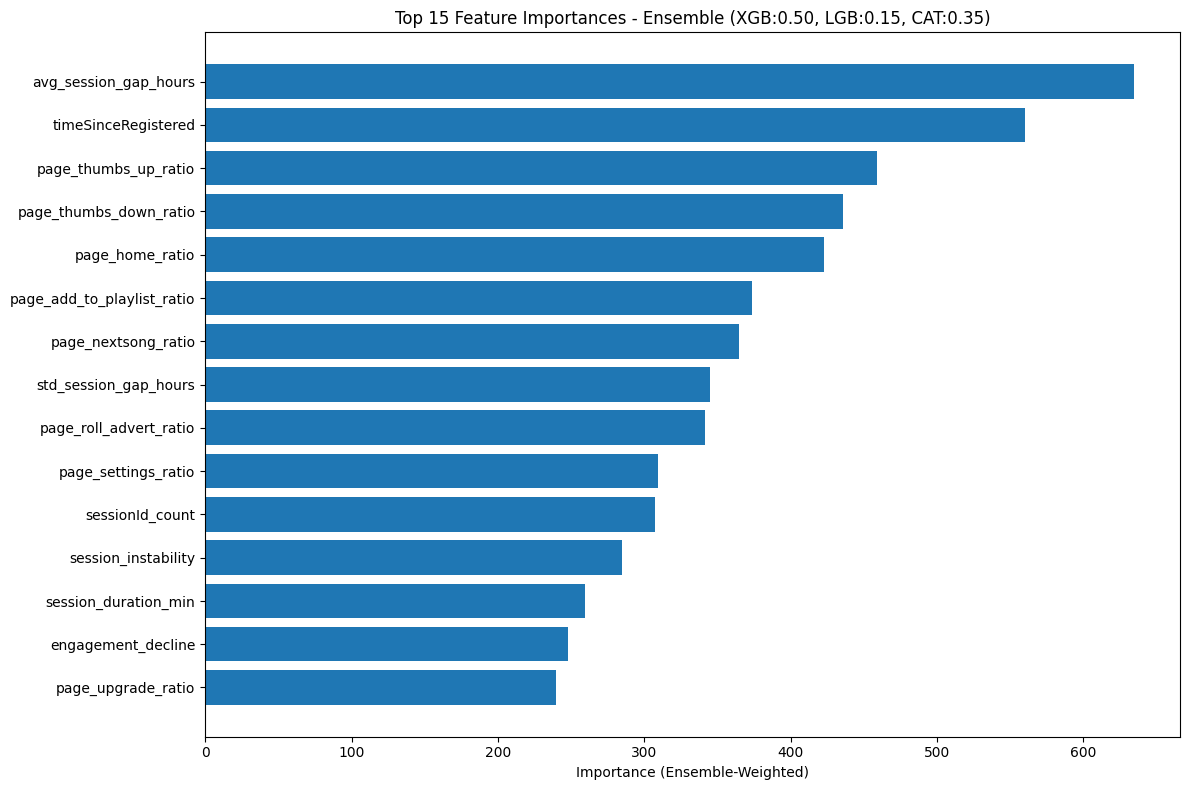

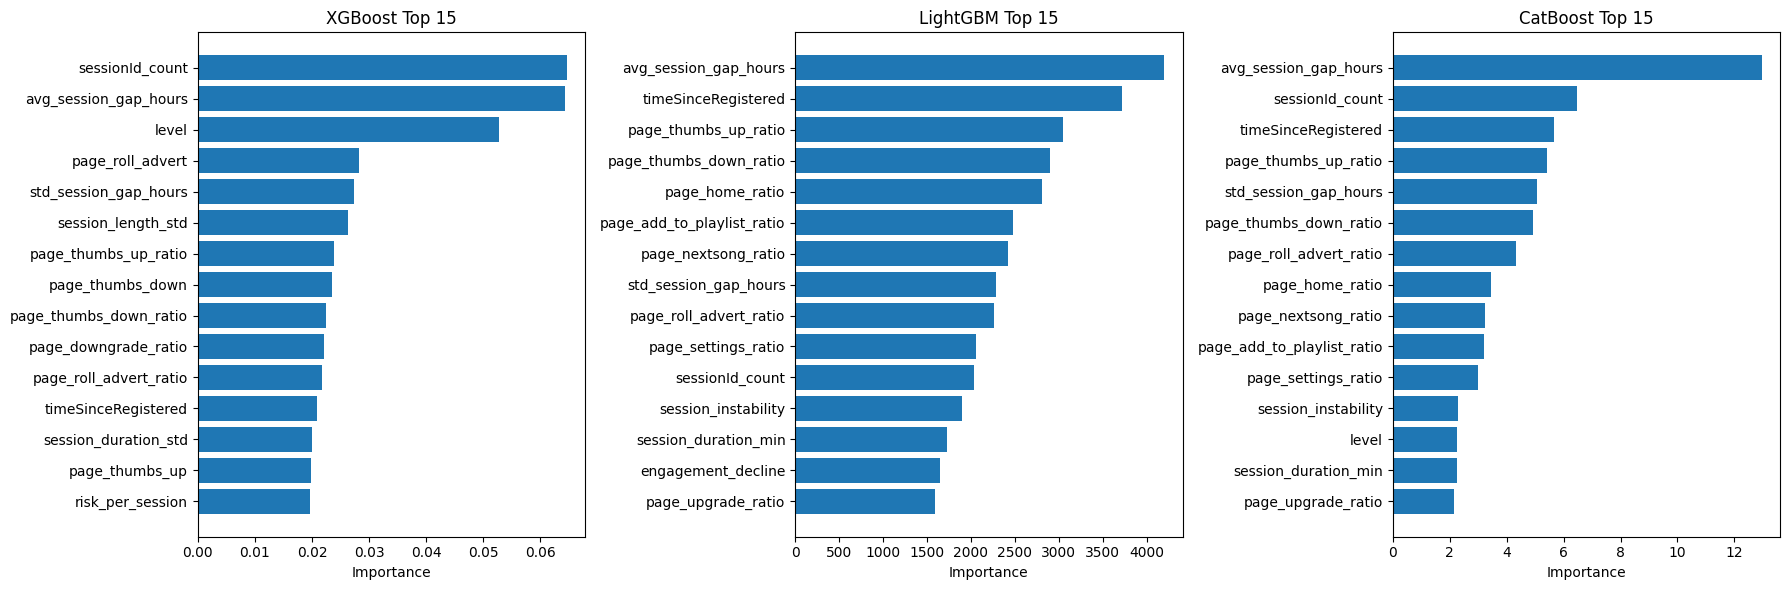


FEATURE IMPORTANCE SUMMARY
Total features: 48
Top 10 features account for: 424791.00% of total importance
Top 20 features account for: 662274.71% of total importance


In [33]:


import matplotlib.pyplot as plt

feature_names = X_user.columns.tolist()

# Get feature importances from all 3 models
xgb_importance = final_xgb.feature_importances_
lgb_importance = final_lgb.feature_importances_
cat_importance = final_cat.feature_importances_

# Weighted average based on ensemble weights
ensemble_importance = (
    best_config['xgb'] * xgb_importance +
    best_config['lgb'] * lgb_importance +
    best_config['cat'] * cat_importance
)

# Create DataFrame
feature_importance = pd.DataFrame({
    'feature': feature_names,
    'xgb_importance': xgb_importance,
    'lgb_importance': lgb_importance,
    'cat_importance': cat_importance,
    'ensemble_importance': ensemble_importance
}).sort_values('ensemble_importance', ascending=False)

print("\n" + "="*70)
print("TOP 20 FEATURES (ENSEMBLE-WEIGHTED)")
print("="*70)
print(feature_importance.head(20)[['feature', 'ensemble_importance']].to_string(index=False))

# Plot top 15 features
plt.figure(figsize=(12, 8))
top_features = feature_importance.head(15)
plt.barh(range(len(top_features)), top_features['ensemble_importance'].values)
plt.yticks(range(len(top_features)), top_features['feature'].values)
plt.xlabel('Importance (Ensemble-Weighted)')
plt.title(f'Top 15 Feature Importances - Ensemble (XGB:{best_config["xgb"]:.2f}, LGB:{best_config["lgb"]:.2f}, CAT:{best_config["cat"]:.2f})')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Individual model comparisons
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# XGBoost
top_xgb = feature_importance.nlargest(15, 'xgb_importance')
axes[0].barh(range(len(top_xgb)), top_xgb['xgb_importance'].values)
axes[0].set_yticks(range(len(top_xgb)))
axes[0].set_yticklabels(top_xgb['feature'].values)
axes[0].set_xlabel('Importance')
axes[0].set_title('XGBoost Top 15')
axes[0].invert_yaxis()

# LightGBM
top_lgb = feature_importance.nlargest(15, 'lgb_importance')
axes[1].barh(range(len(top_lgb)), top_lgb['lgb_importance'].values)
axes[1].set_yticks(range(len(top_lgb)))
axes[1].set_yticklabels(top_lgb['feature'].values)
axes[1].set_xlabel('Importance')
axes[1].set_title('LightGBM Top 15')
axes[1].invert_yaxis()

# CatBoost
top_cat = feature_importance.nlargest(15, 'cat_importance')
axes[2].barh(range(len(top_cat)), top_cat['cat_importance'].values)
axes[2].set_yticks(range(len(top_cat)))
axes[2].set_yticklabels(top_cat['feature'].values)
axes[2].set_xlabel('Importance')
axes[2].set_title('CatBoost Top 15')
axes[2].invert_yaxis()

plt.tight_layout()
plt.show()

# Summary statistics
print("\n" + "="*70)
print("FEATURE IMPORTANCE SUMMARY")
print("="*70)
print(f"Total features: {len(feature_names)}")
print(f"Top 10 features account for: {feature_importance.head(10)['ensemble_importance'].sum():.2%} of total importance")
print(f"Top 20 features account for: {feature_importance.head(20)['ensemble_importance'].sum():.2%} of total importance")

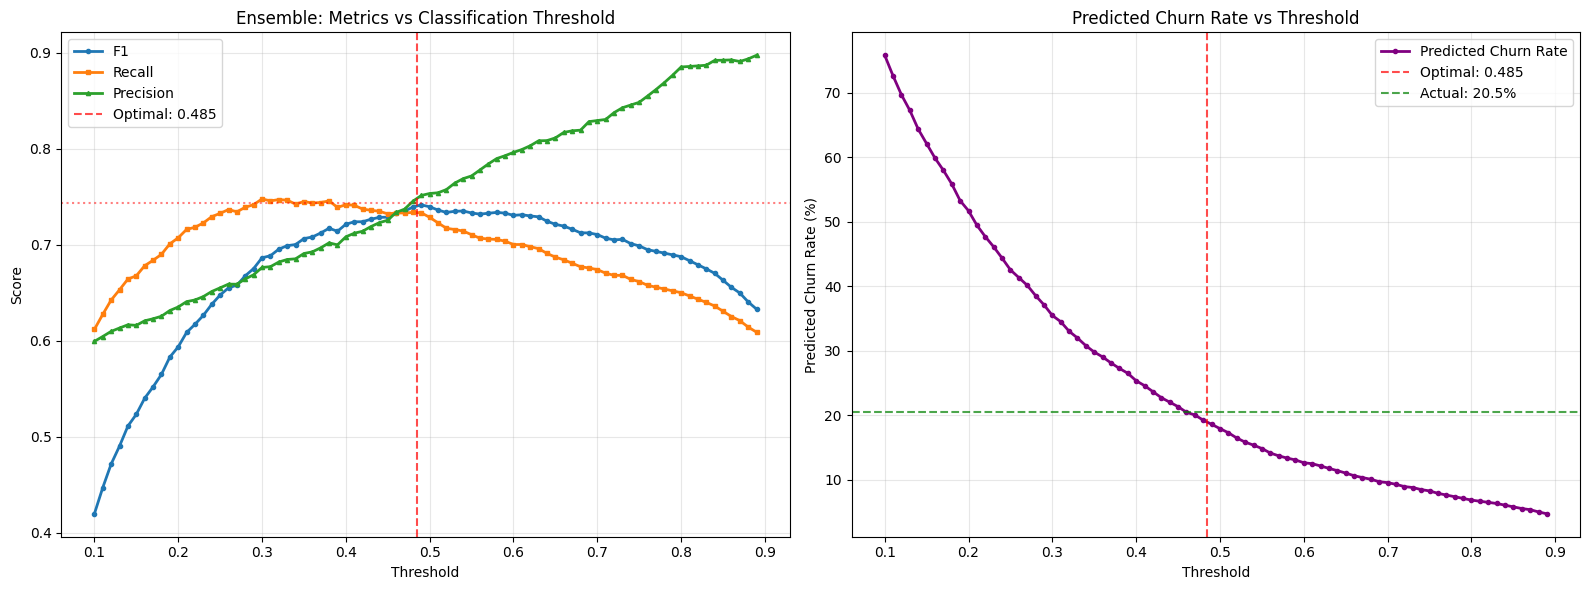


THRESHOLD OPTIMIZATION RESULTS

✓ Optimal threshold: 0.490
✓ Best F1-score: 0.7416
✓ Recall at optimal: 0.7334
✓ Precision at optimal: 0.7515
✓ Predicted churn rate: 18.57%
✓ Actual churn rate: 20.49%

TOP 10 THRESHOLDS BY F1-SCORE
 threshold       f1   recall  precision  pred_churn_rate
      0.49 0.741649 0.733387   0.751456         0.185681
      0.50 0.739640 0.728664   0.753497         0.178987
      0.48 0.739313 0.733827   0.745462         0.192084
      0.51 0.736269 0.722865   0.754251         0.172584
      0.54 0.735276 0.714399   0.768981         0.153376
      0.47 0.735143 0.733169   0.737202         0.200233
      0.53 0.734991 0.715937   0.764382         0.158033
      0.58 0.733821 0.705589   0.789911         0.133295
      0.52 0.733730 0.717270   0.757616         0.164435
      0.46 0.733532 0.733286   0.733780         0.204307

INDIVIDUAL MODEL OPTIMAL THRESHOLDS
XGBoost: threshold=0.580, F1=0.7377
LightGBM: threshold=0.500, F1=0.7300
CatBoost: threshold=0.610, F1=

In [ ]:
# Get ensemble probabilities on validation set
ens_val_proba = (best_config['xgb'] * xgb_proba + 
                 best_config['lgb'] * lgb_proba + 
                 best_config['cat'] * cat_proba)

# Test thresholds
thresholds = np.arange(0.1, 0.9, 0.01)  # Fine-grained for better visualization
threshold_results = []

for threshold in thresholds:
    y_pred_thresh = (ens_val_proba >= threshold).astype(int)
    
    f1 = f1_score(y_val, y_pred_thresh, average='macro')
    recall = recall_score(y_val, y_pred_thresh, average='macro')
    precision = precision_score(y_val, y_pred_thresh, average='macro')
    
    # Additional metrics
    pred_churn_rate = y_pred_thresh.mean()
    
    threshold_results.append({
        'threshold': threshold,
        'f1': f1,
        'recall': recall,
        'precision': precision,
        'pred_churn_rate': pred_churn_rate
    })

threshold_df = pd.DataFrame(threshold_results)

# Plot main metrics
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left plot: F1, Recall, Precision
axes[0].plot(threshold_df['threshold'], threshold_df['f1'], 'o-', label='F1', linewidth=2, markersize=3)
axes[0].plot(threshold_df['threshold'], threshold_df['recall'], 's-', label='Recall', linewidth=2, markersize=3)
axes[0].plot(threshold_df['threshold'], threshold_df['precision'], '^-', label='Precision', linewidth=2, markersize=3)
axes[0].axvline(best_config['threshold'], color='red', linestyle='--', alpha=0.7, label=f'Optimal: {best_config["threshold"]:.3f}')
axes[0].axhline(best_f1, color='red', linestyle=':', alpha=0.5)
axes[0].set_xlabel('Threshold')
axes[0].set_ylabel('Score')
axes[0].set_title('Ensemble: Metrics vs Classification Threshold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Right plot: Predicted churn rate
axes[1].plot(threshold_df['threshold'], threshold_df['pred_churn_rate'] * 100, 'o-', 
             color='purple', linewidth=2, markersize=3, label='Predicted Churn Rate')
axes[1].axvline(best_config['threshold'], color='red', linestyle='--', alpha=0.7, 
                label=f'Optimal: {best_config["threshold"]:.3f}')
axes[1].axhline(y_val.mean() * 100, color='green', linestyle='--', alpha=0.7, 
                label=f'Actual: {y_val.mean()*100:.1f}%')
axes[1].set_xlabel('Threshold')
axes[1].set_ylabel('Predicted Churn Rate (%)')
axes[1].set_title('Predicted Churn Rate vs Threshold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Find optimal and show top results
optimal_row = threshold_df.loc[threshold_df['f1'].idxmax()]

print(f"Optimal threshold: {optimal_row['threshold']:.3f}")
print(f"Best F1-score: {optimal_row['f1']:.4f}")
print(f"Recall at optimal: {optimal_row['recall']:.4f}")
print(f"Precision at optimal: {optimal_row['precision']:.4f}")
print(f"Predicted churn rate: {optimal_row['pred_churn_rate']*100:.2f}%")
print(f"Actual churn rate: {y_val.mean()*100:.2f}%")


print(threshold_df.nlargest(10, 'f1')[['threshold', 'f1', 'recall', 'precision', 'pred_churn_rate']].to_string(index=False))

# Compare with individual models

# XGBoost
xgb_threshold_results = []
for threshold in np.arange(0.1, 0.9, 0.01):
    y_pred = (xgb_proba >= threshold).astype(int)
    f1 = f1_score(y_val, y_pred, average='macro')
    xgb_threshold_results.append({'threshold': threshold, 'f1': f1})
xgb_threshold_df = pd.DataFrame(xgb_threshold_results)
xgb_best = xgb_threshold_df.loc[xgb_threshold_df['f1'].idxmax()]
print(f"XGBoost: threshold={xgb_best['threshold']:.3f}, F1={xgb_best['f1']:.4f}")

# LightGBM
lgb_threshold_results = []
for threshold in np.arange(0.1, 0.9, 0.01):
    y_pred = (lgb_proba >= threshold).astype(int)
    f1 = f1_score(y_val, y_pred, average='macro')
    lgb_threshold_results.append({'threshold': threshold, 'f1': f1})
lgb_threshold_df = pd.DataFrame(lgb_threshold_results)
lgb_best = lgb_threshold_df.loc[lgb_threshold_df['f1'].idxmax()]
print(f"LightGBM: threshold={lgb_best['threshold']:.3f}, F1={lgb_best['f1']:.4f}")

# CatBoost
cat_threshold_results = []
for threshold in np.arange(0.1, 0.9, 0.01):
    y_pred = (cat_proba >= threshold).astype(int)
    f1 = f1_score(y_val, y_pred, average='macro')
    cat_threshold_results.append({'threshold': threshold, 'f1': f1})
cat_threshold_df = pd.DataFrame(cat_threshold_results)
cat_best = cat_threshold_df.loc[cat_threshold_df['f1'].idxmax()]
print(f"CatBoost: threshold={cat_best['threshold']:.3f}, F1={cat_best['f1']:.4f}")

print(f"Ensemble: threshold={optimal_row['threshold']:.3f}, F1={optimal_row['f1']:.4f} ⭐")

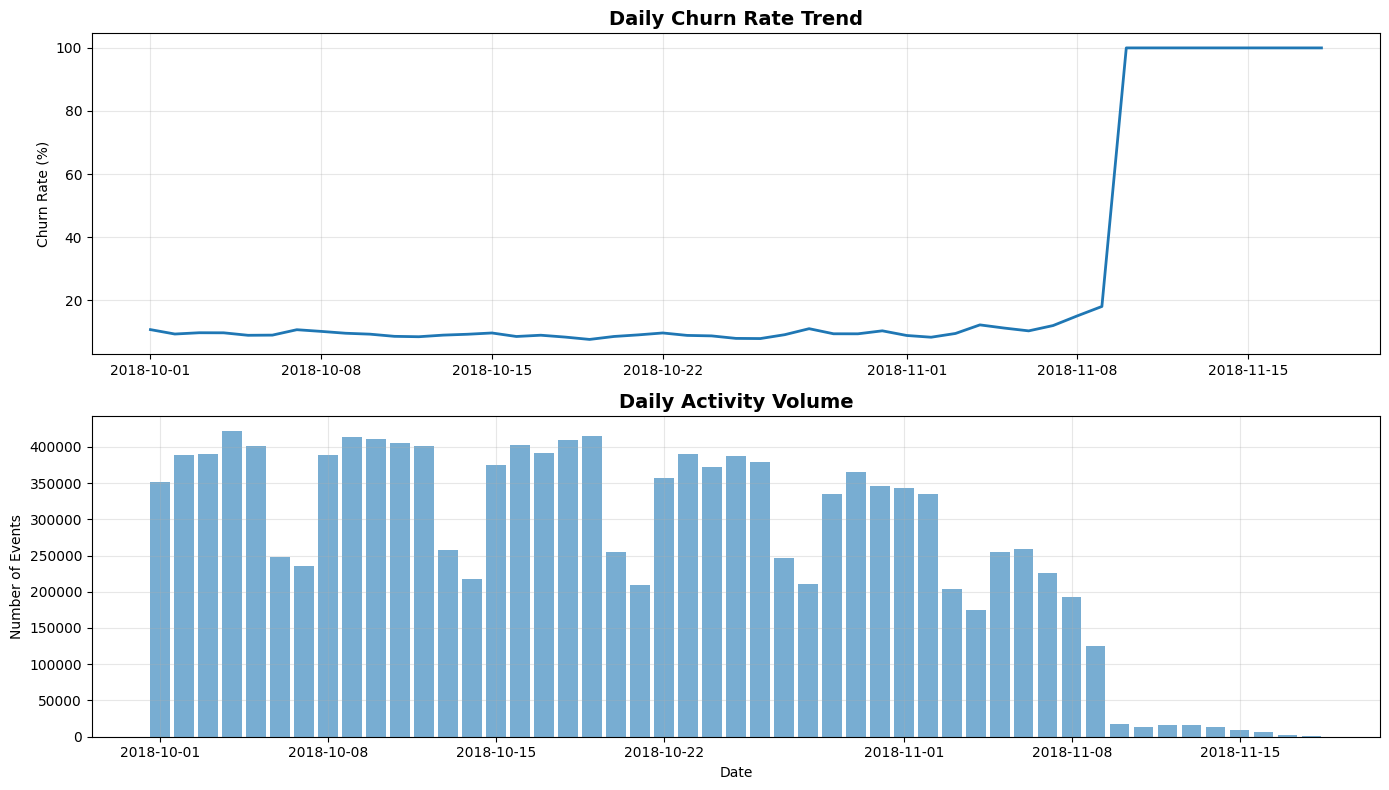

Overall churn rate: 10.05%
Peak churn rate: 100.00%
Minimum churn rate: 7.53%


In [30]:
# === ENHANCED EDA: Temporal Churn Analysis ===

import seaborn as sns
import matplotlib.pyplot as plt

# 1. Churn rate over time
df_train['date'] = df_train['ts'].dt.date
daily_churn = df_train.groupby('date')['will_churn_in_10d'].agg(['mean', 'sum', 'count'])

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Churn rate trend
axes[0].plot(daily_churn.index, daily_churn['mean'] * 100, linewidth=2)
axes[0].set_title('Daily Churn Rate Trend', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Churn Rate (%)')
axes[0].grid(alpha=0.3)

# Activity volume
axes[1].bar(daily_churn.index, daily_churn['count'], alpha=0.6)
axes[1].set_title('Daily Activity Volume', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Number of Events')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Overall churn rate: {df_train['will_churn_in_10d'].mean():.2%}")
print(f"Peak churn rate: {daily_churn['mean'].max():.2%}")
print(f"Minimum churn rate: {daily_churn['mean'].min():.2%}")

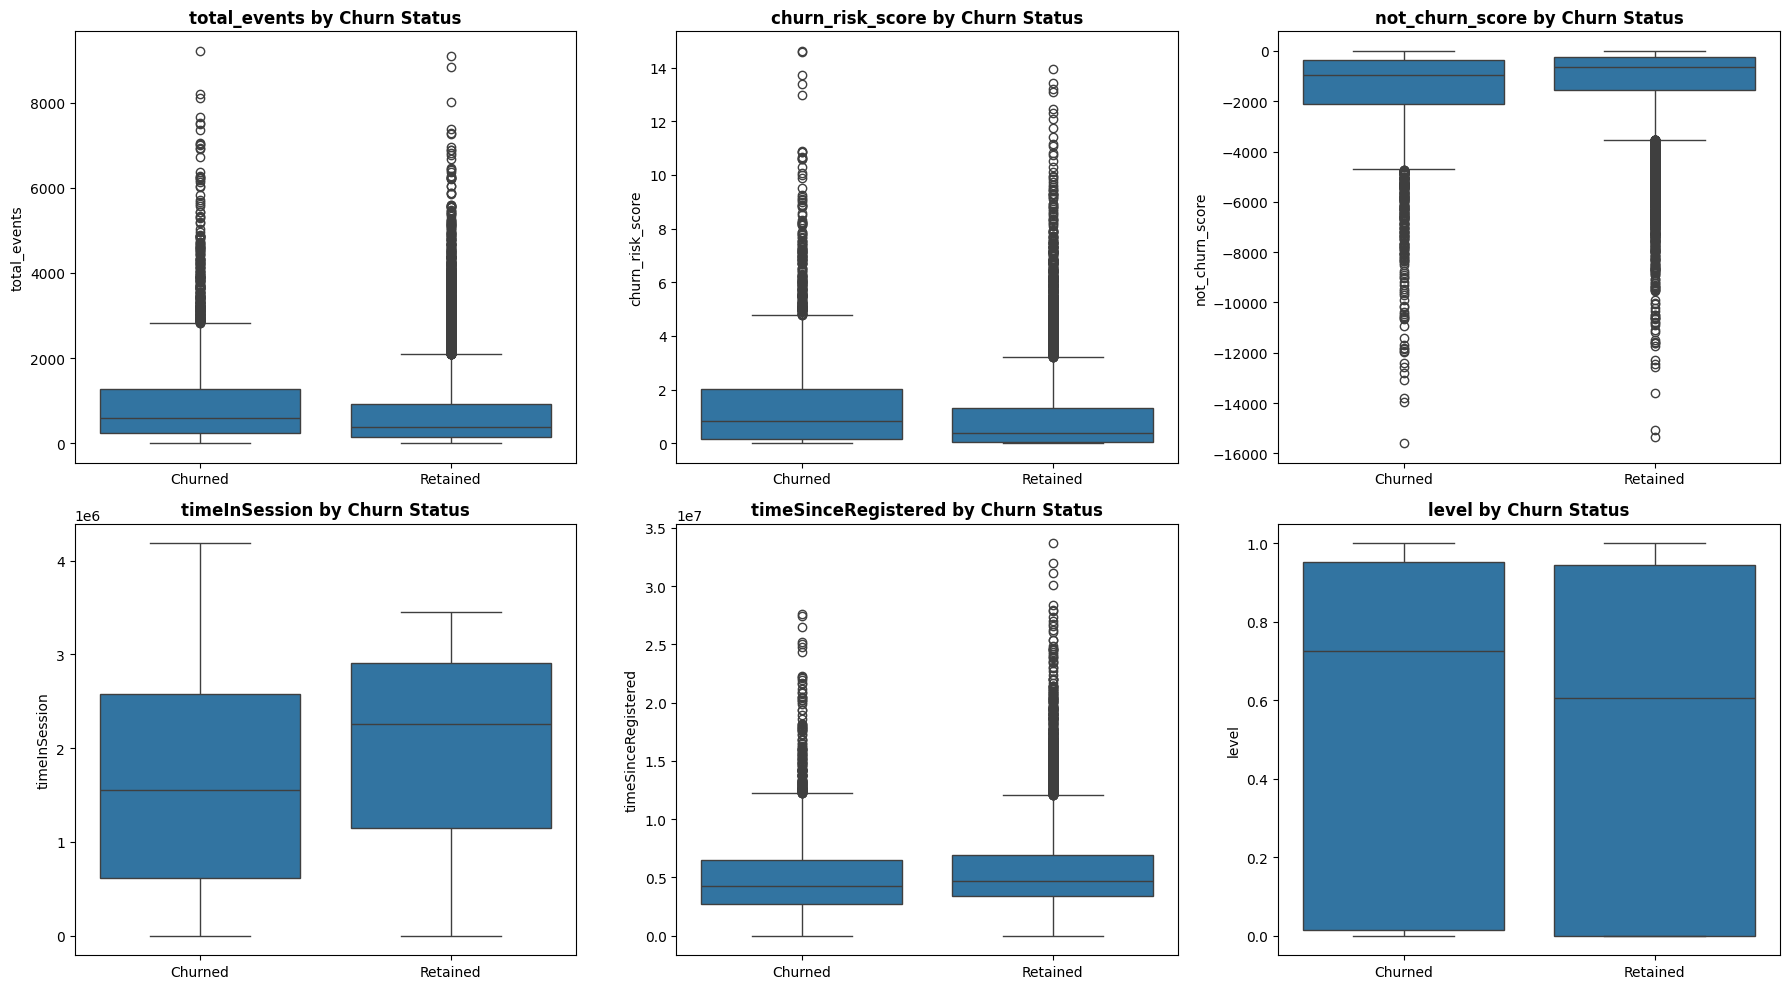


CHURNED vs RETAINED USERS - Statistical Summary
                         Retained       Churned
total_events         7.056453e+02  9.508636e+02
churn_risk_score     9.530939e-01  1.420878e+00
not_churn_score     -1.182528e+03 -1.590724e+03
timeInSession        1.971385e+06  1.648231e+06
timeSinceRegistered  5.590134e+06  5.046569e+06
level                4.943710e-01  5.714598e-01


In [31]:
# === USER-LEVEL ANALYSIS ===

# Aggregate user behavior
user_stats = df_train.groupby('userId').agg({
    'will_churn_in_10d': 'max',  # User will churn
    'itemInSession': 'max',       # Max items in a session
    'timeInSession': 'max',       # Max session duration
    'timeSinceRegistered': 'max', # Account age
    'churn_risk_score': 'max',    # Peak risk score
    'not_churn_score': 'min',     # Minimum retention score
    'level': 'mean',               # Avg subscription level
    'status': 'count'              # Total events
}).rename(columns={'status': 'total_events'})

user_stats['churn_label'] = user_stats['will_churn_in_10d'].map({0: 'Retained', 1: 'Churned'})

# Visualize key differences
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

features_to_plot = ['total_events', 'churn_risk_score', 'not_churn_score', 
                    'timeInSession', 'timeSinceRegistered', 'level']

for idx, feature in enumerate(features_to_plot):
    sns.boxplot(data=user_stats, x='churn_label', y=feature, ax=axes[idx])
    axes[idx].set_title(f'{feature} by Churn Status', fontweight='bold')
    axes[idx].set_xlabel('')

plt.tight_layout()
plt.show()

# Statistical comparison
print("\n" + "="*70)
print("CHURNED vs RETAINED USERS - Statistical Summary")
print("="*70)
comparison = user_stats.groupby('will_churn_in_10d')[features_to_plot].mean()
comparison.index = ['Retained', 'Churned']
print(comparison.T)

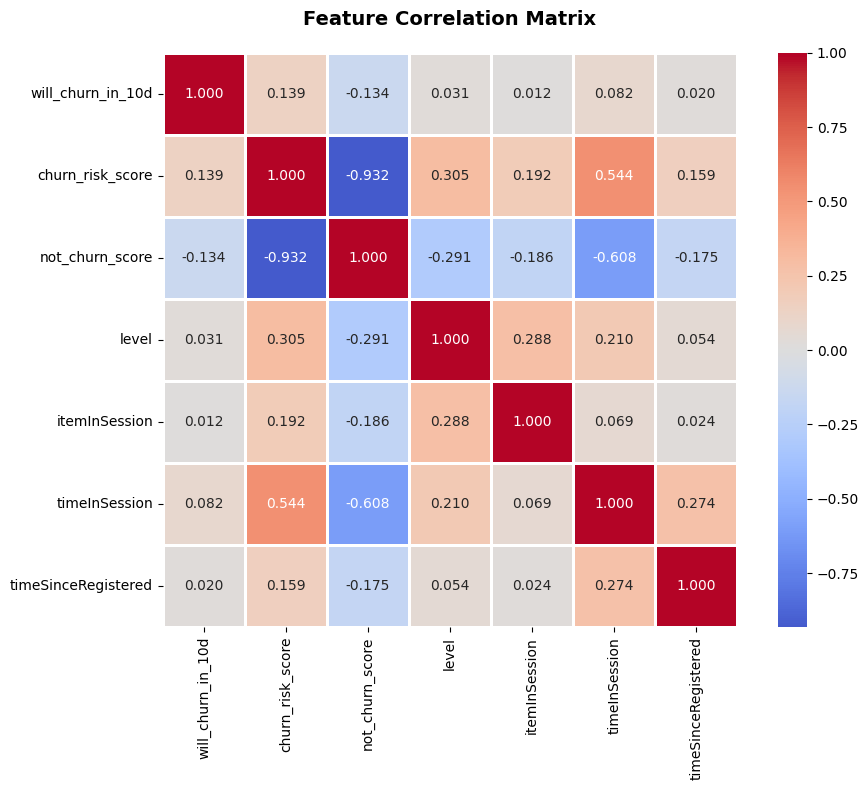


Correlation with Churn Target:
churn_risk_score       0.138663
timeInSession          0.082038
level                  0.030796
timeSinceRegistered    0.019535
itemInSession          0.011501
not_churn_score       -0.134220
Name: will_churn_in_10d, dtype: float64


In [32]:
# === CORRELATION ANALYSIS ===

# Feature correlations with churn
correlation_features = ['will_churn_in_10d', 'churn_risk_score', 'not_churn_score', 
                        'level', 'itemInSession', 'timeInSession', 'timeSinceRegistered']

correlation_matrix = df_train[correlation_features].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt='.3f', cmap='coolwarm', 
            center=0, square=True, linewidths=1)
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Correlation with target
target_corr = correlation_matrix['will_churn_in_10d'].drop('will_churn_in_10d').sort_values(ascending=False)
print("\nCorrelation with Churn Target:")
print(target_corr)